<a href="https://colab.research.google.com/github/joshualewin6/Colab-Notebook/blob/main/JoshLewiU9proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI to Guess the Letter
(Right off the bat, huge shout out to Grant for helping me with all the code for data wrangling. If it weren't for him, I would have no data, no way to view my AI's guesses, and/or have infinitely scaling test loss. Thank you, Grant.)

##Introduction
For my final model of the year, I'm going to make an AI that says what letter it thinks is written based on images of handwritten characters 0-9, A-Z, and a-z. We'll start importing some things like data and libraries.

In [1]:
!pip install scikit-learn

###Bad Import Attempt
The next three code blocks are the initial data wrangling attempt, where I tried to decompose the images into their simplified 64 axes, but it wasn't working right, since I couldn't put the data in a pandas table. However, the image compressing and decompressing functions come in handy later when viewing examples.

In [2]:
from sklearn.decomposition import PCA
import numpy
import pickle as pk
import urllib.request

link='https://raw.githubusercontent.com/CMDRZero/DataScienceFundamentalsClass/refs/heads/main/pca-JL-letters.pk'
f=urllib.request.urlopen(link)
pca=pk.load(f)


In [3]:
pca

PCA(n_components=64)

In [4]:
SCALE=8

def DownScale(img):
    return img[::SCALE, ::SCALE, 0]

def UpScale(img):
    return numpy.kron(img.reshape(img.shape+(1,)), numpy.ones((SCALE, SCALE, 3)))

def Down(img):
    return Compress(DownScale(img))

def Up(img):
    return UpScale(DeCompress(img))

def Compress(img):
    return pca.transform(img.flatten().reshape((1,)+img.flatten().shape))[0]

def DeCompress(img):
    return pca.inverse_transform(img.flatten().reshape((1,)+img.shape))[0].reshape(imshape)

imshape = (113,150)

###Good Data Import
Instead I just imported the images as a data table from Grant's GitHub.

In [5]:
import pandas

In [10]:
letters=pandas.read_csv('https://raw.githubusercontent.com/CMDRZero/DataScienceFundamentalsClass/refs/heads/main/JL-data.csv') #55 of each of the 62 characters, each image with 64 axes that determine its appearance
letters

,name,axis_0,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,...,axis_54,axis_55,axis_56,axis_57,axis_58,axis_59,axis_60,axis_61,axis_62,axis_63
0,frames/img001-001.png,-2074.784919,-191.130982,-1164.214147,111.800735,3132.739597,-1130.414852,-2491.932241,1664.477192,1455.049700,...,291.496413,-686.653671,174.791440,1091.800266,-779.154347,-765.102668,-425.256409,-240.224484,-229.450803,527.288946
1,frames/img001-002.png,-2305.724166,265.474877,-1867.672631,1597.401582,-1915.369001,1282.114100,2932.710717,3019.349723,-740.115992,...,-354.656522,-435.084618,-30.785743,-3.133206,-79.932216,-95.785198,-307.310062,368.084248,-184.431520,-54.216343
2,frames/img001-003.png,1457.204324,4115.867451,-2482.583425,9.885879,749.569626,261.032446,-2959.369438,836.138698,448.040137,...,126.083519,304.031484,-1125.589280,-107.035606,-539.573387,-522.807227,1322.306351,-13.456943,326.406807,979.697425
3,frames/img001-004.png,-1170.397699,-1213.537665,1810.668339,852.923291,36.748693,1130.505301,853.612868,-811.804735,-666.524979,...,-182.819390,190.827294,87.575378,417.161693,-50.787789,-243.201433,76.303755,-33.856159,186.142991,46.962870
4,frames/img001-005.png,-363.389436,-954.218955,869.280398,-553.661763,-1427.195157,1560.807481,1196.195920,1246.153263,-138.743070,...,-334.498973,-734.719907,547.493154,173.738967,-212.503606,413.107293,164.696484,426.864152,72.965554,-21.880374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3405,frames/img062-051.png,-3114.657792,1045.653865,-613.893706,634.489192,451.208311,-1021.706532,-1338.281642,-1830.631666,264.625588,...,32.995666,-5.610385,-198.450719,559.196370,-90.768806,-536.878619,-282.831463,-55.965829,91.291461,170.224817
3406,frames/img062-052.png,-1122.364496,-1191.903246,1433.772377,-523.811320,414.314268,1279.258078,-285.262157,-212.620922,-102.132530,...,61.275090,186.857839,-96.587990,-339.452080,-510.511574,142.989131,452.069323,167.932102,-145.609912,387.477442
3407,frames/img062-053.png,-1052.884140,-530.579303,2416.452936,-785.806474,642.889311,-99.447693,-774.269987,-878.380895,203.180327,...,360.128737,92.057664,-176.976173,263.734562,-535.014910,-236.511621,-160.228414,179.671490,136.160620,27.182192
3408,frames/img062-054.png,-1417.954213,-914.477923,2011.186033,-37.262222,-44.770014,231.992489,-931.574952,-1698.663173,53.254796,...,363.809889,510.696551,-312.936713,137.289861,-409.019141,116.730183,44.005808,20.655589,179.908024,564.035389


In [8]:
import torch

##Data Wrangling
The next 5 cell blocks involved making X and Y tensors that a torch model could process. This meant normalizing axis values and the making the categorical variable into booleans and then floats.

In [11]:
letters=letters.drop('name', axis=1)
X=letters
X=X.to_numpy()
Xstd=numpy.std(X,axis=0)
Xmu=numpy.mean(X,axis=0)
X_orig=X
X=(X-numpy.expand_dims(Xmu,axis=0))/numpy.expand_dims(Xstd,axis=0)
X=torch.from_numpy(X)
X


tensor([[-0.9745,  0.1076, -0.8705,  ..., -0.7280, -0.7765,  1.6911],
        [-1.1224,  0.4081, -1.3905,  ...,  1.0719, -0.6374, -0.1906],
        [ 1.2874,  2.9419, -1.8452,  ..., -0.0570,  0.9411,  3.1551],
        ...,
        [-0.3201, -0.1158,  1.7768,  ...,  0.5144,  0.3532,  0.0728],
        [-0.5539, -0.3684,  1.4771,  ...,  0.0439,  0.4884,  1.8100],
        [-1.3574,  0.1841,  0.0752,  ..., -0.9364, -0.4820, -3.1526]],
       dtype=torch.float64)

In [12]:
cats=[]
for i in range(10):
  cats+=[chr(ord('0')+i)]*55
for i in range(26):
  cats+=[chr(ord('A')+i)]*55
for i in range(26):
  cats+=[chr(ord('a')+i)]*55

In [13]:
Y=cats
Y= pandas.get_dummies(Y,columns=['letter'], drop_first=False)
Y=torch.from_numpy(Y.to_numpy().astype(numpy.float64))
Y

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 1.]], dtype=torch.float64)

##The Model
We're going with a simple linear model. If it sucks, we'll change it, but for now we have plenty of good data to work with, so the assumption is it won't be terrible.

In [14]:
import torch
import numpy as np
from torch import nn
import pandas as pd
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [23]:
linear = torch.nn.Linear(in_features=64, # in_features: must match column number of input
                         out_features=62,# out_features: column number of output
                         dtype=torch.float64) #specifies the data type
y_pred = linear(X) #the actual matrix multiplication
print(f"Input shape: {X.shape}\n")
print(f"Output:\n{y_pred}\n\nOutput shape: {y_pred.shape}")

Input shape: torch.Size([3410, 64])

Output:
tensor([[-2.1058, -1.3673,  0.4827,  ...,  0.9391, -0.3907,  0.9334],
        [-0.6821,  0.2262,  0.2893,  ...,  0.1394, -0.4002,  0.2802],
        [-0.4789,  0.0335,  1.3677,  ...,  0.9441,  0.5825, -0.2368],
        ...,
        [-0.2368, -0.2904,  0.0467,  ..., -0.4230, -0.0103,  0.1316],
        [-0.3056, -0.2886,  0.1413,  ..., -0.2472, -0.4760,  0.0363],
        [ 0.0991, -0.2004,  0.2745,  ..., -0.8285,  0.1291,  0.4384]],
       dtype=torch.float64, grad_fn=<AddmmBackward0>)

Output shape: torch.Size([3410, 62])


In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2) #splitting into training and testing data

In [25]:
# Create a loss function
loss_fn = nn.MSELoss() # mean squared error; this is similar to multiplying our matrix by itself

# Create an optimizer; SGD is stochastic gradient decent
optimizer = torch.optim.SGD(params=linear.parameters(),
                            lr=0.1) #this is how fast it optimizes; smaller is slower, but more consistent

In [26]:
# Set the number of epochs; this is how many times we update our model
epochs = 5000

for epoch in range(epochs):
    ### Training

    #this allows our matrices to update
    linear.train()

    # 1. Forward pass; makes predictions
    y_pred = linear(X_train)

    # 2. Calculate loss; how bad were our predictions?
    loss = loss_fn(y_pred, Y_train)

    # 3. Optimizer zero grad; resets how we change our model
    optimizer.zero_grad()

    # 4. Loss backwards; determines how to change our weights matrix
    loss.backward()

    # 5. Optimizer step; changes our weights matrix based on .backward()
    optimizer.step()

    ### Testing
    linear.eval() #forces our matrices to stay the same
    with torch.inference_mode():
      # 1. Forward pass; makes predictions, but with test data
      test_pred = linear(X_test)
      # 2. Calculate the loss, but with test data
      test_loss = loss_fn(test_pred, Y_test)

    # Print out what's happening
    if epoch % 50 == 0: #prints every 100 epochs
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.35005, Test loss: 0.34928
Epoch: 50 | Train loss: 0.24594, Test loss: 0.24798
Epoch: 100 | Train loss: 0.17719, Test loss: 0.18053
Epoch: 150 | Train loss: 0.13097, Test loss: 0.13478
Epoch: 200 | Train loss: 0.09934, Test loss: 0.10319
Epoch: 250 | Train loss: 0.07731, Test loss: 0.08099
Epoch: 300 | Train loss: 0.06171, Test loss: 0.06512
Epoch: 350 | Train loss: 0.05048, Test loss: 0.05361
Epoch: 400 | Train loss: 0.04228, Test loss: 0.04512
Epoch: 450 | Train loss: 0.03621, Test loss: 0.03878
Epoch: 500 | Train loss: 0.03165, Test loss: 0.03399
Epoch: 550 | Train loss: 0.02819, Test loss: 0.03032
Epoch: 600 | Train loss: 0.02553, Test loss: 0.02748
Epoch: 650 | Train loss: 0.02346, Test loss: 0.02525
Epoch: 700 | Train loss: 0.02184, Test loss: 0.02350
Epoch: 750 | Train loss: 0.02056, Test loss: 0.02210
Epoch: 800 | Train loss: 0.01954, Test loss: 0.02098
Epoch: 850 | Train loss: 0.01872, Test loss: 0.02007
Epoch: 900 | Train loss: 0.01806, Test loss: 0.01

##Results
They're ideal. Despite 0, O, and o being nearly indistinguishable, as well as I, l, and 1, plus many letters and their corresponding capitals, the AI has a test loss of 0.01533, under 2 percent, which is really good. It's nearly perfect, and I don't think more nodes will be necessary. Below is a test to see what the AI's top choices are. The confidence values in the tensor go in order for 0-9, A-Z, and a-z

<ipython-input-27-4dda76676f01>:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Xreal=X_0*Xstd+Xmu


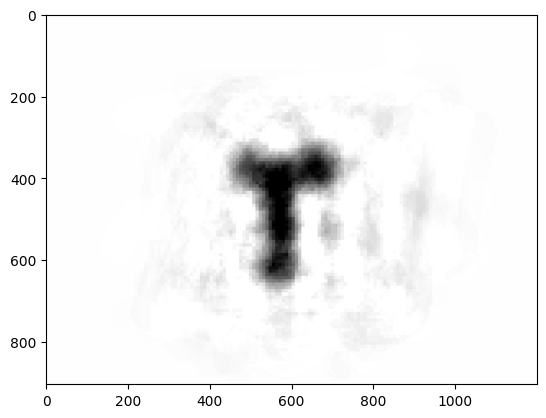

In [27]:
X_0=X_test[0]
Xreal=X_0*Xstd+Xmu
Ximg=Up(Xreal)
plt.imshow(Ximg/256)


In [20]:
print(linear(X_0))

tensor([-0.0039,  0.0591, -0.0271,  0.0025,  0.0323,  0.0518,  0.0027, -0.0029,
         0.0105,  0.0269, -0.0333,  0.0285,  0.0064,  0.0131,  0.0079, -0.0390,
        -0.0349, -0.0191,  0.0459,  0.0295,  0.0167,  0.0496,  0.0143,  0.0035,
        -0.0129, -0.0104, -0.0538, -0.0516,  0.0398,  0.0388,  0.0197,  0.0384,
        -0.0349, -0.0018,  0.0364, -0.0358,  0.0111,  0.0473,  0.0310, -0.0100,
         0.0514,  0.0585,  0.1028, -0.0266, -0.0209,  0.0888,  0.0072,  0.0208,
        -0.0422,  0.0287,  0.0420,  0.0419,  0.0904,  0.0385,  0.0341,  0.0402,
         0.0028,  0.0227, -0.0124,  0.0107,  0.0958,  0.0354],
       dtype=torch.float64, grad_fn=<ViewBackward0>)


##Conclusion
The model does very well with the letters. Future improvements may include adding a ReLU layer, a sigmoid layer, or increasing the number of nodes. Overall, it's a success.